In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

df = pd.read_csv("../data/neurosense_dataset.csv")

print(df.shape)
df.head()
df.columns

(37575, 346)


Index(['subject', 'session', 'trial', 'sample', 'label', 'eeg_feature_1',
       'eeg_feature_2', 'eeg_feature_3', 'eeg_feature_4', 'eeg_feature_5',
       ...
       'eye_feature_22', 'eye_feature_23', 'eye_feature_24', 'eye_feature_25',
       'eye_feature_26', 'eye_feature_27', 'eye_feature_28', 'eye_feature_29',
       'eye_feature_30', 'eye_feature_31'],
      dtype='str', length=346)

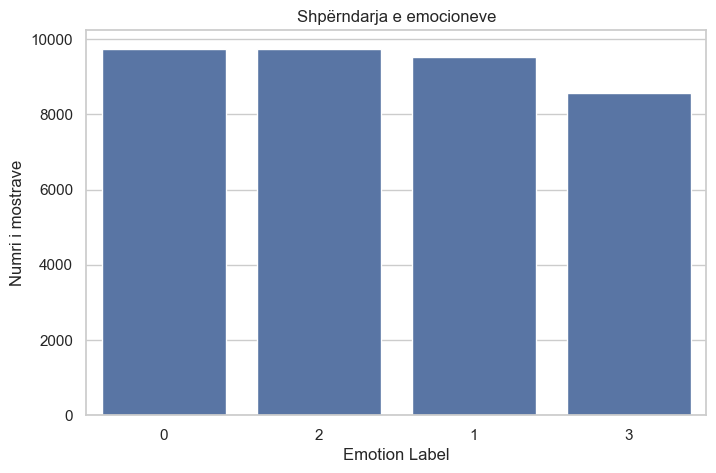

label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title("Shpërndarja e emocioneve")
plt.xlabel("Emotion Label")
plt.ylabel("Numri i mostrave")

plt.show()

print(df["label"].value_counts())

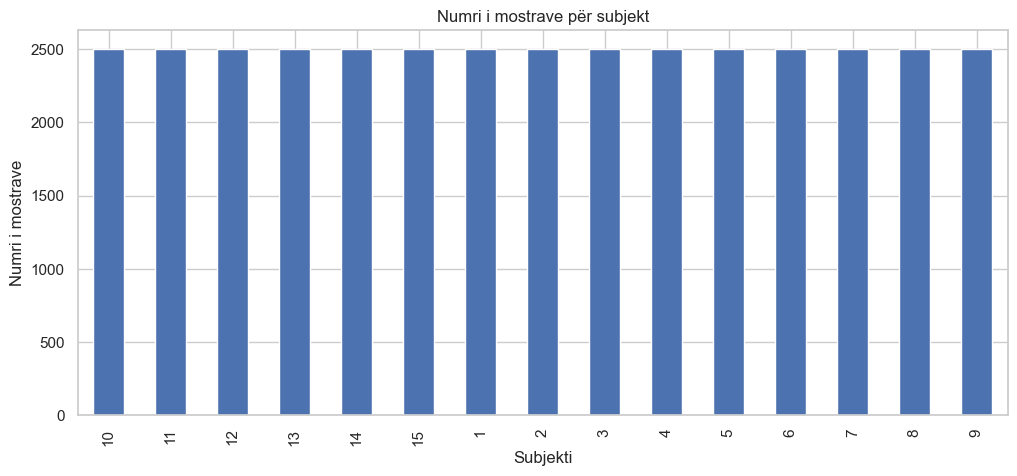

In [ ]:
#Numri i mostrave për secilin subjekt
subject_counts = df["subject"].value_counts()

plt.figure(figsize=(12,5))

subject_counts.plot(kind="bar")

plt.title("Numri i mostrave për subjekt")
plt.xlabel("Subjekti")
plt.ylabel("Numri i mostrave")

plt.show()

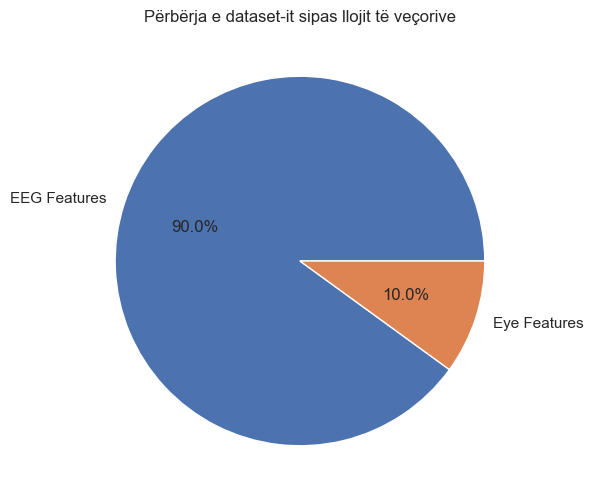

In [5]:
#EEG vs Eye Features
feature_types = {
    "EEG Features": 279,
    "Eye Features": 31
}

plt.figure(figsize=(6,6))

plt.pie(
    feature_types.values(),
    labels=feature_types.keys(),
    autopct="%1.1f%%"
)

plt.title("Përbërja e dataset-it sipas llojit të veçorive")

plt.show()

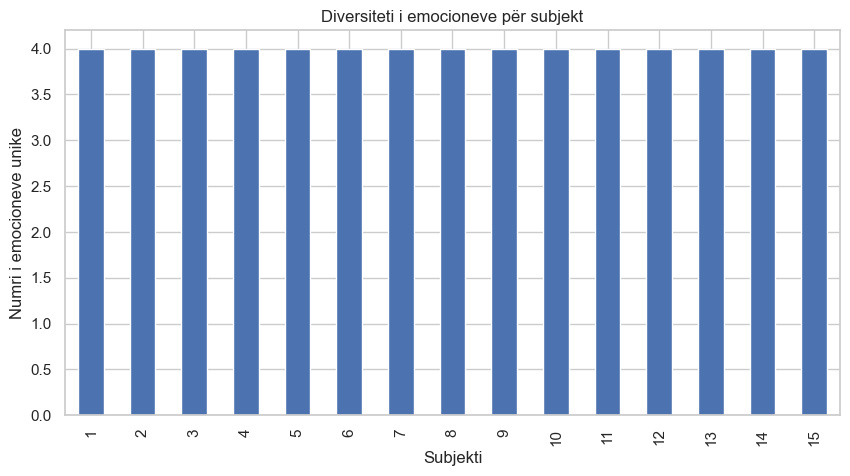

In [6]:
#Cilët subjekte përjetojnë më shumë emocione të ndryshme?
emotion_diversity = (
    df.groupby("subject")["label"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

emotion_diversity.plot(kind="bar")

plt.title("Diversiteti i emocioneve për subjekt")
plt.xlabel("Subjekti")
plt.ylabel("Numri i emocioneve unike")

plt.show()

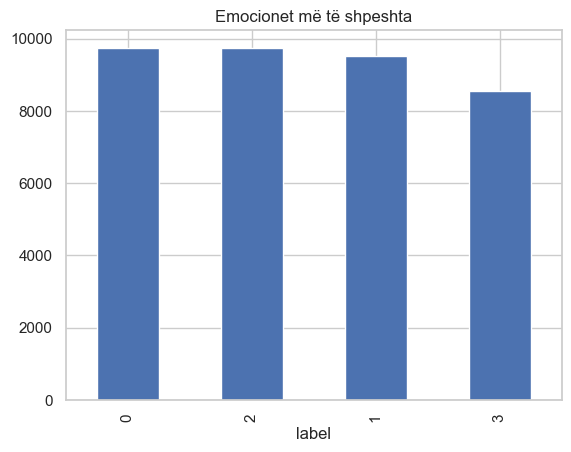

In [8]:
#=emocionet më të shpeshta
df["label"].value_counts().head(10).plot(kind="bar")
plt.title("Emocionet më të shpeshta")
plt.show()

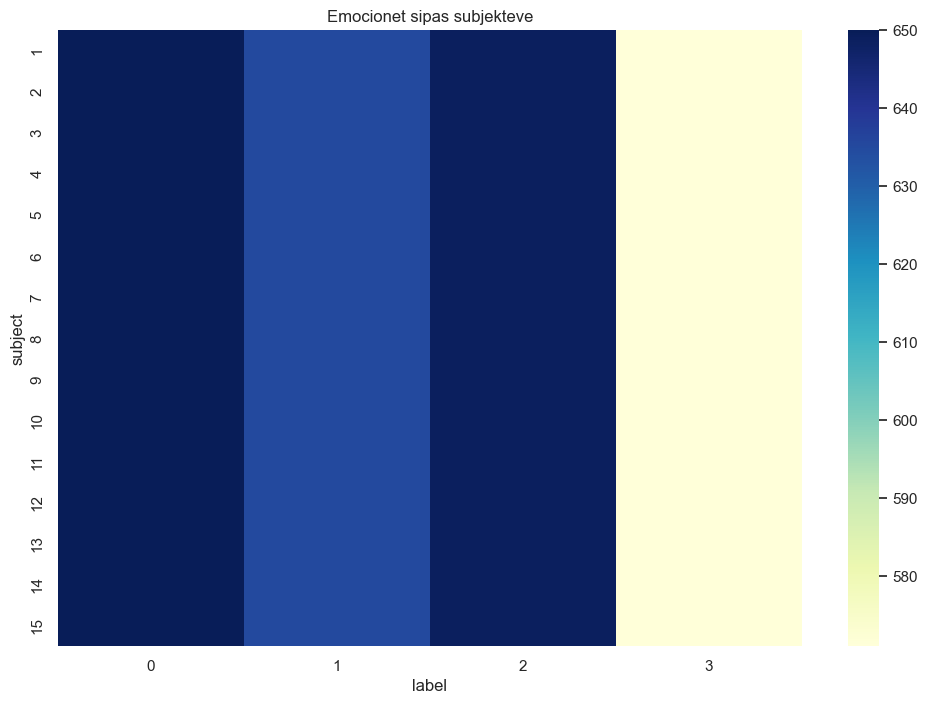

In [9]:
#Heatmap e emocioneve sipas subjektit
emotion_subject = pd.crosstab(df["subject"], df["label"])

plt.figure(figsize=(12,8))
sns.heatmap(emotion_subject, cmap="YlGnBu")
plt.title("Emocionet sipas subjekteve")
plt.show()

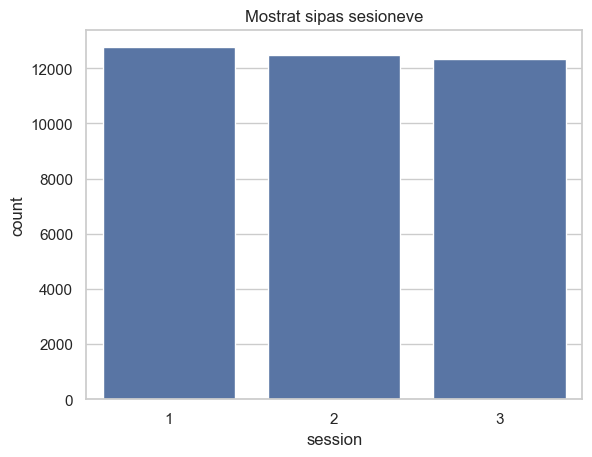

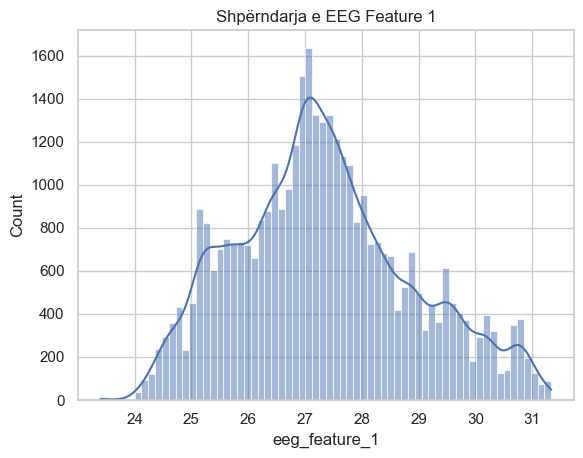

In [11]:
#Numri i mostrave për session
sns.countplot(data=df, x="session")
plt.title("Mostrat sipas sesioneve")
plt.show()
sns.histplot(df["eeg_feature_1"], kde=True)
plt.title("Shpërndarja e EEG Feature 1")
plt.show()

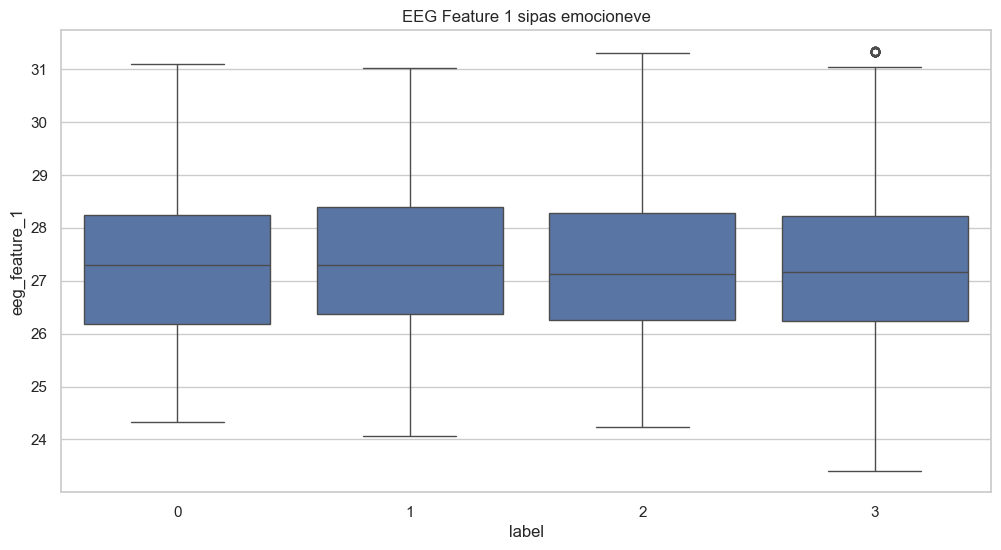

In [12]:
#Krahasimi i EEG Feature sipas emocioneve
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="label",
    y="eeg_feature_1"
)

plt.title("EEG Feature 1 sipas emocioneve")
plt.show()

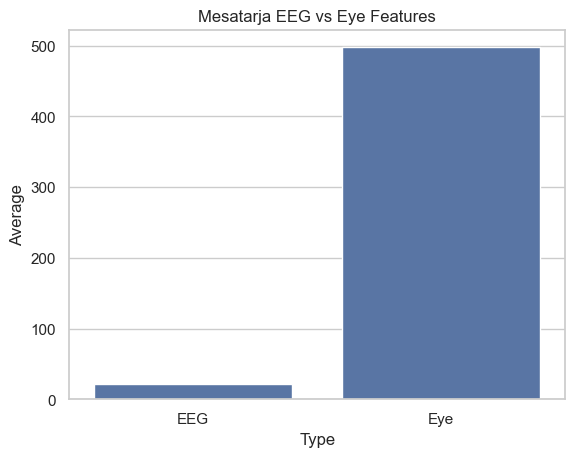

In [13]:
#EEG vs Eye Tracking
eeg_cols = [c for c in df.columns if "eeg_feature" in c]
eye_cols = [c for c in df.columns if "eye_feature" in c]

comparison = pd.DataFrame({
    "Type": ["EEG", "Eye"],
    "Average": [
        df[eeg_cols].mean().mean(),
        df[eye_cols].mean().mean()
    ]
})

sns.barplot(data=comparison, x="Type", y="Average")
plt.title("Mesatarja EEG vs Eye Features")
plt.show()

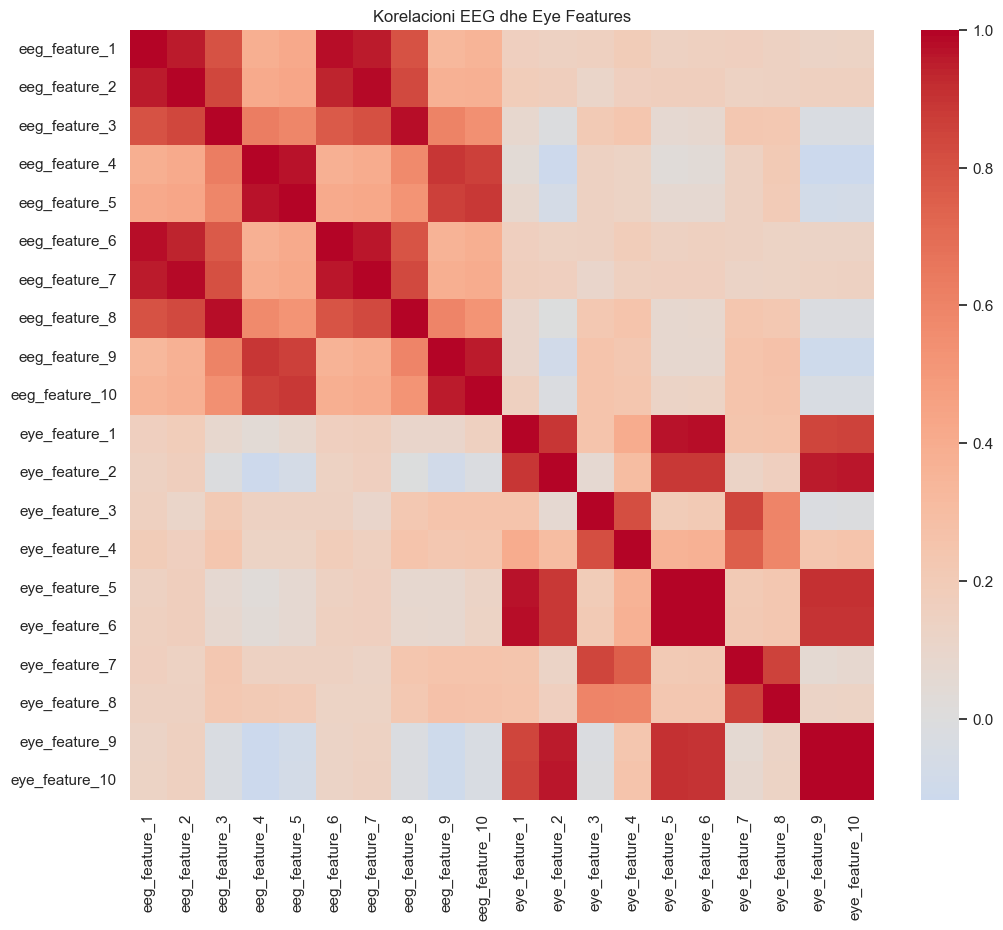

In [ ]:
#Korelacioni mes EEG dhe Eye Features
selected = eeg_cols[:10] + eye_cols[:10]

corr = df[selected].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Korelacioni EEG dhe Eye Features")
plt.show()